In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import os
import pandas as pd

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [3]:
subdirectories = ['Hydrogen', 'Carbon dioxide', 'Ammonia', 'Methanol', 'Ethylene']
GWPFilePaths = [os.path.join('..', 'Results', 'Phase 2', subdir, f'{subdir.lower()} climate change results.xlsx') for subdir in subdirectories]

In [4]:
for GWPFilePath in GWPFilePaths:
    
    dfs = pd.read_excel(GWPFilePath, sheet_name = None)
    dfAll = []

    for df in dfs.items():
        database = df[0]
        df = df[1]
        numCols = len(df.columns) - 1
        repeatedActivity = np.repeat(df['Activity'], numCols)
        dfNew = pd.DataFrame({
            'Activity' : repeatedActivity,
            'Location' : np.tile(df.columns[1:], len(df)),
            'GWP' : df.iloc[:, 1:].values.flatten(),
            'Database' : database
        })
        dfAll.append(dfNew)

    GWPDF = pd.concat(dfAll, ignore_index = True)
    GWPDF = GWPDF.sort_values('Activity')

    if 'Hydrogen' in GWPFilePath:
        hydrogenGWPDF = GWPDF
        hydrogenBAUGWP = [row['GWP'] for index, row in hydrogenGWPDF.iterrows() if 'steam reforming' in row['Activity']
                                 and 'without electricity' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'biomethane' not in row['Activity']][0]
    elif 'Ammonia' in GWPFilePath:
        ammoniaGWPDF = GWPDF
        ammoniaBAUGWP = [row['GWP'] for index, row in ammoniaGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'Methanol' in GWPFilePath:
        methanolGWPDF = GWPDF
        methanolBAUGWP = [row['GWP'] for index, row in methanolGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'Ethylene' in GWPFilePath:
        ethyleneGWPDF = GWPDF
        ethyleneBAUGWP = [row['GWP'] for index, row in ethyleneGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]

In [5]:
def replace_values(df):
    df = df.copy()
    df['Database'] = df['Database'].str.replace('Base', 'RCP6')
    df['Database'] = df['Database'].str.replace('PkBudg500', 'RCP19')
    df['Database'] = df['Database'].str.replace('PkBudg1150', 'RCP26')
    return df

hydrogenGWPDF = replace_values(hydrogenGWPDF)
# carbonDioxideGWPDF = replace_values(carbonDioxideGWPDF)
ammoniaGWPDF = replace_values(ammoniaGWPDF)
methanolGWPDF = replace_values(methanolGWPDF)
ethyleneGWPDF = replace_values(ethyleneGWPDF)

In [6]:
hydrogenGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = hydrogenGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
# carbonDioxideGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = carbonDioxideGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
ammoniaGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = ammoniaGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
methanolGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = methanolGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
ethyleneGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = ethyleneGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')

hydrogenGWPDF['Pathway'] = hydrogenGWPDF['IAM'] + ' ' + hydrogenGWPDF['SSP'] + ' ' + hydrogenGWPDF['RCP']
# carbonDioxideGWPDF['Pathway'] = carbonDioxideGWPDF['IAM'] + ' ' + carbonDioxideGWPDF['SSP'] + ' ' + carbonDioxideGWPDF['RCP']
ammoniaGWPDF['Pathway'] = ammoniaGWPDF['IAM'] + ' ' + ammoniaGWPDF['SSP'] + ' ' + ammoniaGWPDF['RCP']
methanolGWPDF['Pathway'] = methanolGWPDF['IAM'] + ' ' + methanolGWPDF['SSP'] + ' ' + methanolGWPDF['RCP']
ethyleneGWPDF['Pathway'] = ethyleneGWPDF['IAM'] + ' ' + ethyleneGWPDF['SSP'] + ' ' + ethyleneGWPDF['RCP']

In [7]:
regionGroups = {
    'BRA' : ['Brazil'],
    'CAN' : ['Canada'],
    'CEU' : ['Albania', 'Bosnia and Herzegovina', 'Bulgaria', 'Cyprus', 'Czechia', 'Estonia', 'Croatia', 'Hungary', 'Lithuania',
             'Latvia', 'North Macedonia', 'Poland', 'Romania', 'Republic of Serbia', 'Slovenia', 'Slovakia', 'Kosovo', 'Northern Cyprus'],
    'CHN' : ['China', 'Mongolia', 'Taiwan'],
    'EAF' : ['Eritrea', 'Ethiopia', 'Kenya', 'Madagascar', 'Mauritius', 'Rwanda', 'Sudan', 'South Sudan', 'Somalia', 'Burundi', 'Djibouti',
             'Somaliland'],
    'INDIA' : ['India'],
    'INDO' : ['Indonesia', 'Papua New Guinea'],
    'JPN' : ['Japan'],
    'KOR' : ['North Korea', 'South Korea'],
    'ME' : ['United Arab Emirates', 'Bahrain', 'Israel', 'Iraq', 'Iran', 'Jordan', 'Kuwait', 'Lebanon', 'Montenegro', 'Saudi Arabia',
            'Oman', 'Yemen', 'Syria', 'Qatar', 'Palestine'],
    'MEX' : ['Mexico'],
    'NAF' : ['Algeria', 'Egypt', 'Libya', 'Morocco', 'Tunisia', 'Western Sahara'],
    'OCE' : ['Australia', 'New Zealand', 'Fiji', 'Vanuatu', 'New Caledonia', 'Solomon Islands'],
    'RCAM' : ['Costa Rica', 'Cuba', 'Curaçao', 'Dominican Republic', 'Guatemala', 'Honduras', 'Haiti', 'Jamaica', 'Nicaragua',
             'El Salvador', 'Trinidad and Tobago', 'The Bahamas', 'Puerto Rico', 'Panama', 'Belize'],
    'RSAF' : ['Angola', 'Botswana', 'Mozambique', 'Namibia', 'United Republic of Tanzania', 'Zambia', 'Zimbabwe', 'Malawi', 'eSwatini', 'Lesotho', 'Uganda'],
    'RSAM' : ['Argentina', 'Falkland Is.', 'Bolivia', 'Chile', 'Colombia', 'Ecuador', 'Peru', 'Paraguay', 'Uruguay', 'Venezuela',
             'Guyana', 'Suriname'],
    'RSAS' : ['Bangladesh', 'Sri Lanka', 'Nepal', 'Pakistan', 'Bhutan', 'Afghanistan'],
    'RUS' : ['Armenia', 'Azerbaijan', 'Georgia', 'Russia'],
    'SAF' : ['South Africa'],
    'SEAS' : ['Brunei', 'Cambodia', 'Myanmar', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam', 'Laos'],
    'STAN' : ['Kyrgyzstan', 'Kazakhstan', 'Tajikistan', 'Turkmenistan', 'Uzbekistan'],
    'TUR' : ['Turkey'],
    'UKR' : ['Belarus', 'Moldova', 'Ukraine'],
    'USA' : ['United States of America'],
    'WAF' : ['Benin', 'Democratic Republic of the Congo', 'Republic of the Congo', 'Ivory Coast', 'Cameroon', 'Gabon', 'Gambia', 'Ghana', 'Niger', 'Nigeria',
             'Senegal', 'Togo', 'Mauritania', 'Mali', 'Burkina Faso', 'Chad', 'Central African Republic', 'Guinea-Bissau', 'Guinea',
             'Sierra Leone', 'Liberia', 'Equatorial Guinea'],
    'WEU' : ['Austria', 'Belgium', 'Switzerland', 'Germany', 'Denmark', 'Spain', 'Finland', 'France', 'United Kingdom', 'Gibraltar',
             'Greece', 'Ireland', 'Iceland', 'Italy', 'Luxembourg', 'Malta', 'Netherlands', 'Norway', 'Portugal', 'Sweden'],
}

In [8]:
newLocations = {'BR' : 'BRA',
                'CA' : 'CAN',
                'PL' : 'CEU',
                'CN' : 'CHN',
                'ET' : 'EAF',
                'IN' : 'INDIA',
                'ID' : 'INDO',
                'JP' : 'JPN',
                'KR' : 'KOR',
                'IR' : 'ME',
                'MX' : 'MEX',
                'EG' : 'NAF',
                'AU' : 'OCE',
                'GT' : 'RCAM',
                'BW' : 'RSAF',
                'CL' : 'RSAM',
                'PK' : 'RSAS',
                'RU' : 'RUS',
                'ZA' : 'SAF',
                'PH' : 'SEAS',
                'UZ' : 'STAN',
                'TR' : 'TUR',
                'UA' : 'UKR',
                'US' : 'USA',
                'NG' : 'WAF',
                'RER' : 'WEU'}

In [9]:
def find_key_by_value(dictionary, value):
    for key, val in dictionary.items():
        if key == value:
            return key
    return None

In [10]:
for key, value in newLocations.items():
    hydrogenGWPDF['Location'] = hydrogenGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    ammoniaGWPDF['Location'] = ammoniaGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    methanolGWPDF['Location'] = methanolGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    ethyleneGWPDF['Location'] = ethyleneGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))

In [11]:
# Define a custom color map from white to a specific color
colors = ['#D8D8D8', '#000000']  
cmapName = 'fossilColorMap'
customFossilMap = mcolors.LinearSegmentedColormap.from_list(cmapName, colors)

colors = ['#C5B3E5', '#52318E']  
cmapName = 'blueColorMap'
customBlueMap = mcolors.LinearSegmentedColormap.from_list(cmapName, colors)

colors = ['#FCACA6', '#B71205'] 
cmapName = 'solarColorMap'
customSolarMap = mcolors.LinearSegmentedColormap.from_list(cmapName, colors)

colors = ['#9EE1f1', '#167F99'] 
cmapName = 'windColorMap'
customWindMap = mcolors.LinearSegmentedColormap.from_list(cmapName, colors)

In [12]:
def plot_world_maps(title, dfRCP62030, dfRCP192030, dfRCP62050, dfRCP192050, cmap):
    
    fig, ([ax1, ax3], [ax2, ax4]) = plt.subplots(2, 2, figsize = (fig_length[2], fig_height*0.4))
    plt.subplots_adjust(wspace = 0.1)

    world = gpd.read_file(r'/Users/abhinabera/Downloads/110m_cultural/ne_110m_admin_0_countries.shp')

    # Filter out Antarctica and Greenland
    world = world[world['SOVEREIGNT'] != 'Antarctica']
    world = world[world['ADMIN'] != 'Greenland']

    # Set up colormap and normalization based on GWP values
    combinedDF = pd.concat([dfRCP62030, dfRCP192030, dfRCP62050, dfRCP192050], ignore_index = True)
    vmin = combinedDF['Percent'].min()
    vmax = combinedDF['Percent'].max()
    norm = plt.Normalize(vmin, vmax)

    ax1.set_title('a 3.5 °C 2030', fontweight = 'bold', fontsize = fontsize_title)
    ax2.set_title('c 1.5 °C 2030', fontweight = 'bold', fontsize = fontsize_title)
    ax3.set_title('b 3.5 °C 2050', fontweight = 'bold', fontsize = fontsize_title)
    ax4.set_title('d 1.5 °C 2050', fontweight = 'bold', fontsize = fontsize_title)
    ax1.set_yticks([])
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax3.set_yticks([])
    ax4.set_xticks([])
    ax4.set_yticks([])

    for region, countries in regionGroups.items():
        region_data = world[world['ADMIN'].isin(countries)]
        gwpValues1 = dfRCP62030[dfRCP62030['Location'] == region]['Percent']
        gwpValues2 = dfRCP192030[dfRCP192030['Location'] == region]['Percent']
        gwpValues3 = dfRCP62050[dfRCP62050['Location'] == region]['Percent']
        gwpValues4 = dfRCP192050[dfRCP192050['Location'] == region]['Percent']
        color1 = cmap(norm(gwpValues1))
        color2 = cmap(norm(gwpValues2))
        color3 = cmap(norm(gwpValues3))
        color4 = cmap(norm(gwpValues4))
        region_data.plot(ax = ax1, color = color1, label = region)
        region_data.plot(ax = ax2, color = color2, label = region)
        region_data.plot(ax = ax3, color = color3, label = region)
        region_data.plot(ax = ax4, color = color4, label = region)
    
    ax1.set_xticks([])
    ax3.set_xticks([])

    # Create a single color bar outside the subplots
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Adjust the position as needed
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cax, orientation='vertical')

    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    
    path = os.path.join('..', 'Results', 'Phase 2', 'Regional global', title)
    plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Regional global', title + '.png')
    plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Regional global', title + '.svg')
    plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
    plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

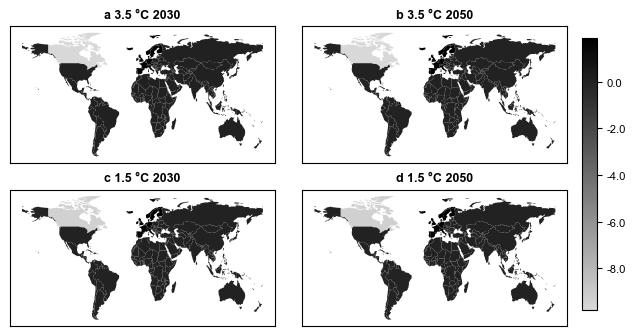

In [13]:
hydrogenRCP6DF = hydrogenGWPDF[hydrogenGWPDF['Database'].str.contains('RCP6')]
fossilHydrogenRCP6DF = hydrogenRCP6DF[
    ~hydrogenRCP6DF['Activity'].str.contains('CCS') &
    hydrogenRCP6DF['Activity'].str.contains('without electricity')
]
fossilHydrogenRCP6DF2030 = fossilHydrogenRCP6DF[fossilHydrogenRCP6DF['Database'].str.contains('2030')].copy()
fossilHydrogenRCP6DF2030GLOGWP = list(fossilHydrogenRCP6DF2030[
    fossilHydrogenRCP6DF2030['Location'] == 'GLO'
]['GWP'])
fossilHydrogenRCP6DF2030.loc[:, 'Percent'] = (
    (fossilHydrogenRCP6DF2030['GWP'] - fossilHydrogenRCP6DF2030GLOGWP[0]) / fossilHydrogenRCP6DF2030GLOGWP[0] * 100
)
fossilHydrogenRCP6DF2030 = fossilHydrogenRCP6DF2030[fossilHydrogenRCP6DF2030['Location'] != 'GLO']
fossilHydrogenRCP6DF2050 = fossilHydrogenRCP6DF[fossilHydrogenRCP6DF['Database'].str.contains('2050')].copy()
fossilHydrogenRCP6DF2050GLOGWP = list(fossilHydrogenRCP6DF2050[
    fossilHydrogenRCP6DF2050['Location'] == 'GLO'
]['GWP'])
fossilHydrogenRCP6DF2050.loc[:, 'Percent'] = (
    (fossilHydrogenRCP6DF2050['GWP'] - fossilHydrogenRCP6DF2050GLOGWP[0]) / fossilHydrogenRCP6DF2050GLOGWP[0] * 100
)
fossilHydrogenRCP6DF2050 = fossilHydrogenRCP6DF2050[fossilHydrogenRCP6DF2050['Location'] != 'GLO']

hydrogenRCP19DF = hydrogenGWPDF[hydrogenGWPDF['Database'].str.contains('RCP19')]
fossilHydrogenRCP19DF = hydrogenRCP19DF[
    ~hydrogenRCP19DF['Activity'].str.contains('CCS') &
    hydrogenRCP19DF['Activity'].str.contains('without electricity')
]
fossilHydrogenRCP19DF2030 = fossilHydrogenRCP19DF[fossilHydrogenRCP19DF['Database'].str.contains('2030')].copy()
fossilHydrogenRCP19DF2030GLOGWP = list(fossilHydrogenRCP19DF2030[
    fossilHydrogenRCP19DF2030['Location'] == 'GLO'
]['GWP'])
fossilHydrogenRCP19DF2030.loc[:, 'Percent'] = (
    (fossilHydrogenRCP19DF2030['GWP'] - fossilHydrogenRCP19DF2030GLOGWP[0]) / fossilHydrogenRCP19DF2030GLOGWP[0] * 100
)
fossilHydrogenRCP19DF2030 = fossilHydrogenRCP19DF2030[fossilHydrogenRCP19DF2030['Location'] != 'GLO']
fossilHydrogenRCP19DF2050 = fossilHydrogenRCP19DF[fossilHydrogenRCP19DF['Database'].str.contains('2050')].copy()
fossilHydrogenRCP19DF2050GLOGWP = list(fossilHydrogenRCP19DF2050[
    fossilHydrogenRCP19DF2050['Location'] == 'GLO'
]['GWP'])
fossilHydrogenRCP19DF2050.loc[:, 'Percent'] = (
    (fossilHydrogenRCP19DF2050['GWP'] - fossilHydrogenRCP19DF2050GLOGWP[0]) / fossilHydrogenRCP19DF2050GLOGWP[0] * 100
)
fossilHydrogenRCP19DF2050 = fossilHydrogenRCP19DF2050[fossilHydrogenRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Fossil hydrogen percent regional', fossilHydrogenRCP6DF2030, fossilHydrogenRCP19DF2030, fossilHydrogenRCP6DF2050, fossilHydrogenRCP19DF2050, customFossilMap)

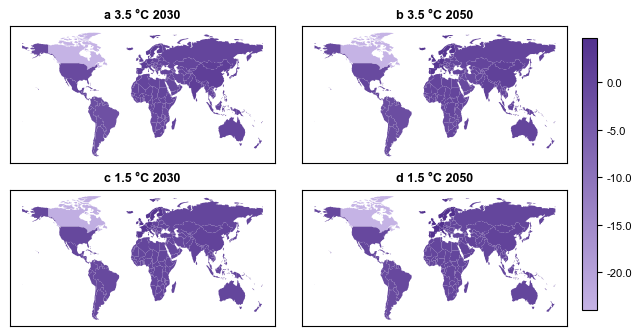

In [14]:
hydrogenRCP6DF = hydrogenGWPDF[hydrogenGWPDF['Database'].str.contains('RCP6')]
blueHydrogenRCP6DF = hydrogenRCP6DF[
    hydrogenRCP6DF['Activity'].str.contains('CCS') &
    hydrogenRCP6DF['Activity'].str.contains('without electricity')
]
blueHydrogenRCP6DF2030 = blueHydrogenRCP6DF[blueHydrogenRCP6DF['Database'].str.contains('2030')].copy()
blueHydrogenRCP6DF2030GLOGWP = list(blueHydrogenRCP6DF2030[
    blueHydrogenRCP6DF2030['Location'] == 'GLO'
]['GWP'])
blueHydrogenRCP6DF2030.loc[:, 'Percent'] = (
    (blueHydrogenRCP6DF2030['GWP'] - blueHydrogenRCP6DF2030GLOGWP[0]) / blueHydrogenRCP6DF2030GLOGWP[0] * 100
)
blueHydrogenRCP6DF2030 = blueHydrogenRCP6DF2030[blueHydrogenRCP6DF2030['Location'] != 'GLO']
blueHydrogenRCP6DF2050 = blueHydrogenRCP6DF[blueHydrogenRCP6DF['Database'].str.contains('2050')].copy()
blueHydrogenRCP6DF2050GLOGWP = list(blueHydrogenRCP6DF2050[
    blueHydrogenRCP6DF2050['Location'] == 'GLO'
]['GWP'])
blueHydrogenRCP6DF2050.loc[:, 'Percent'] = (
    (blueHydrogenRCP6DF2050['GWP'] - blueHydrogenRCP6DF2050GLOGWP[0]) / blueHydrogenRCP6DF2050GLOGWP[0] * 100
)
blueHydrogenRCP6DF2050 = blueHydrogenRCP6DF2050[blueHydrogenRCP6DF2050['Location'] != 'GLO']

hydrogenRCP19DF = hydrogenGWPDF[hydrogenGWPDF['Database'].str.contains('RCP19')]
blueHydrogenRCP19DF = hydrogenRCP19DF[
    hydrogenRCP19DF['Activity'].str.contains('CCS') &
    hydrogenRCP19DF['Activity'].str.contains('without electricity')
]
blueHydrogenRCP19DF2030 = blueHydrogenRCP19DF[blueHydrogenRCP19DF['Database'].str.contains('2030')].copy()
blueHydrogenRCP19DF2030GLOGWP = list(blueHydrogenRCP19DF2030[
    blueHydrogenRCP19DF2030['Location'] == 'GLO'
]['GWP'])
blueHydrogenRCP19DF2030.loc[:, 'Percent'] = (
    (blueHydrogenRCP19DF2030['GWP'] - blueHydrogenRCP19DF2030GLOGWP[0]) / blueHydrogenRCP19DF2030GLOGWP[0] * 100
)
blueHydrogenRCP19DF2030 = blueHydrogenRCP19DF2030[blueHydrogenRCP19DF2030['Location'] != 'GLO']
blueHydrogenRCP19DF2050 = blueHydrogenRCP19DF[blueHydrogenRCP19DF['Database'].str.contains('2050')].copy()
blueHydrogenRCP19DF2050GLOGWP = list(blueHydrogenRCP19DF2050[
    blueHydrogenRCP19DF2050['Location'] == 'GLO'
]['GWP'])
blueHydrogenRCP19DF2050.loc[:, 'Percent'] = (
    (blueHydrogenRCP19DF2050['GWP'] - blueHydrogenRCP19DF2050GLOGWP[0]) / blueHydrogenRCP19DF2050GLOGWP[0] * 100
)
blueHydrogenRCP19DF2050 = blueHydrogenRCP19DF2050[blueHydrogenRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Blue hydrogen percent regional', blueHydrogenRCP6DF2030, blueHydrogenRCP19DF2030, blueHydrogenRCP6DF2050, blueHydrogenRCP19DF2050, customBlueMap)

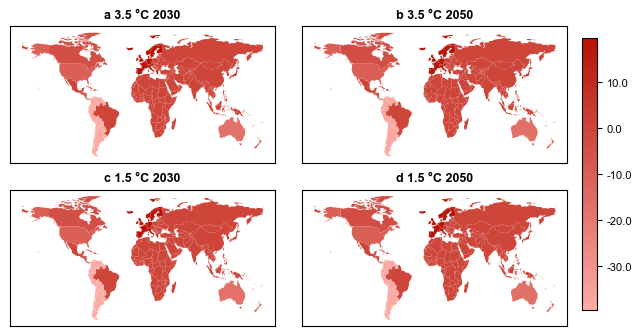

In [15]:
hydrogenRCP6DF = hydrogenGWPDF[hydrogenGWPDF['Database'].str.contains('RCP6')]
solarHydrogenRCP6DF = hydrogenRCP6DF[
    hydrogenRCP6DF['Activity'].str.contains('PEM') &
    hydrogenRCP6DF['Activity'].str.contains('solar')
]
solarHydrogenRCP6DF2030 = solarHydrogenRCP6DF[solarHydrogenRCP6DF['Database'].str.contains('2030')].copy()
solarHydrogenRCP6DF2030GLOGWP = list(solarHydrogenRCP6DF2030[
    solarHydrogenRCP6DF2030['Location'] == 'GLO'
]['GWP'])
solarHydrogenRCP6DF2030.loc[:, 'Percent'] = (
    (solarHydrogenRCP6DF2030['GWP'] - solarHydrogenRCP6DF2030GLOGWP[0]) / solarHydrogenRCP6DF2030GLOGWP[0] * 100
)
solarHydrogenRCP6DF2030 = solarHydrogenRCP6DF2030[solarHydrogenRCP6DF2030['Location'] != 'GLO']
solarHydrogenRCP6DF2050 = solarHydrogenRCP6DF[solarHydrogenRCP6DF['Database'].str.contains('2050')].copy()
solarHydrogenRCP6DF2050GLOGWP = list(solarHydrogenRCP6DF2050[
    solarHydrogenRCP6DF2050['Location'] == 'GLO'
]['GWP'])
solarHydrogenRCP6DF2050.loc[:, 'Percent'] = (
    (solarHydrogenRCP6DF2050['GWP'] - solarHydrogenRCP6DF2050GLOGWP[0]) / solarHydrogenRCP6DF2050GLOGWP[0] * 100
)
solarHydrogenRCP6DF2050 = solarHydrogenRCP6DF2050[solarHydrogenRCP6DF2050['Location'] != 'GLO']

hydrogenRCP19DF = hydrogenGWPDF[hydrogenGWPDF['Database'].str.contains('RCP19')]
solarHydrogenRCP19DF = hydrogenRCP19DF[
    hydrogenRCP19DF['Activity'].str.contains('PEM') &
    hydrogenRCP19DF['Activity'].str.contains('solar')
]
solarHydrogenRCP19DF2030 = solarHydrogenRCP19DF[solarHydrogenRCP19DF['Database'].str.contains('2030')].copy()
solarHydrogenRCP19DF2030GLOGWP = list(solarHydrogenRCP19DF2030[
    solarHydrogenRCP19DF2030['Location'] == 'GLO'
]['GWP'])
solarHydrogenRCP19DF2030.loc[:, 'Percent'] = (
    (solarHydrogenRCP19DF2030['GWP'] - solarHydrogenRCP19DF2030GLOGWP[0]) / solarHydrogenRCP19DF2030GLOGWP[0] * 100
)
solarHydrogenRCP19DF2030 = solarHydrogenRCP19DF2030[solarHydrogenRCP19DF2030['Location'] != 'GLO']
solarHydrogenRCP19DF2050 = solarHydrogenRCP19DF[solarHydrogenRCP19DF['Database'].str.contains('2050')].copy()
solarHydrogenRCP19DF2050GLOGWP = list(solarHydrogenRCP19DF2050[
    solarHydrogenRCP19DF2050['Location'] == 'GLO'
]['GWP'])
solarHydrogenRCP19DF2050.loc[:, 'Percent'] = (
    (solarHydrogenRCP19DF2050['GWP'] - solarHydrogenRCP19DF2050GLOGWP[0]) / solarHydrogenRCP19DF2050GLOGWP[0] * 100
)
solarHydrogenRCP19DF2050 = solarHydrogenRCP19DF2050[solarHydrogenRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Solar hydrogen percent regional', solarHydrogenRCP6DF2030, solarHydrogenRCP19DF2030, solarHydrogenRCP6DF2050, solarHydrogenRCP19DF2050, customSolarMap)

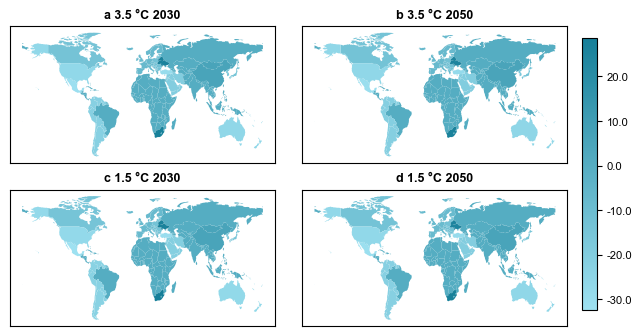

In [16]:
hydrogenRCP6DF = hydrogenGWPDF[hydrogenGWPDF['Database'].str.contains('RCP6')]
windHydrogenRCP6DF = hydrogenRCP6DF[
    hydrogenRCP6DF['Activity'].str.contains('PEM') &
    hydrogenRCP6DF['Activity'].str.contains('onshore wind')
]
windHydrogenRCP6DF2030 = windHydrogenRCP6DF[windHydrogenRCP6DF['Database'].str.contains('2030')].copy()
windHydrogenRCP6DF2030GLOGWP = list(windHydrogenRCP6DF2030[
    windHydrogenRCP6DF2030['Location'] == 'GLO'
]['GWP'])
windHydrogenRCP6DF2030.loc[:, 'Percent'] = (
    (windHydrogenRCP6DF2030['GWP'] - windHydrogenRCP6DF2030GLOGWP[0]) / windHydrogenRCP6DF2030GLOGWP[0] * 100
)
windHydrogenRCP6DF2030 = windHydrogenRCP6DF2030[windHydrogenRCP6DF2030['Location'] != 'GLO']
windHydrogenRCP6DF2050 = windHydrogenRCP6DF[windHydrogenRCP6DF['Database'].str.contains('2050')].copy()
windHydrogenRCP6DF2050GLOGWP = list(windHydrogenRCP6DF2050[
    windHydrogenRCP6DF2050['Location'] == 'GLO'
]['GWP'])
windHydrogenRCP6DF2050.loc[:, 'Percent'] = (
    (windHydrogenRCP6DF2050['GWP'] - windHydrogenRCP6DF2050GLOGWP[0]) / windHydrogenRCP6DF2050GLOGWP[0] * 100
)
windHydrogenRCP6DF2050 = windHydrogenRCP6DF2050[windHydrogenRCP6DF2050['Location'] != 'GLO']

hydrogenRCP19DF = hydrogenGWPDF[hydrogenGWPDF['Database'].str.contains('RCP19')]
windHydrogenRCP19DF = hydrogenRCP19DF[
    hydrogenRCP19DF['Activity'].str.contains('PEM') &
    hydrogenRCP19DF['Activity'].str.contains('onshore wind')
]
windHydrogenRCP19DF2030 = windHydrogenRCP19DF[windHydrogenRCP19DF['Database'].str.contains('2030')].copy()
windHydrogenRCP19DF2030GLOGWP = list(windHydrogenRCP19DF2030[
    windHydrogenRCP19DF2030['Location'] == 'GLO'
]['GWP'])
windHydrogenRCP19DF2030.loc[:, 'Percent'] = (
    (windHydrogenRCP19DF2030['GWP'] - windHydrogenRCP19DF2030GLOGWP[0]) / windHydrogenRCP19DF2030GLOGWP[0] * 100
)
windHydrogenRCP19DF2030 = windHydrogenRCP19DF2030[windHydrogenRCP19DF2030['Location'] != 'GLO']
windHydrogenRCP19DF2050 = windHydrogenRCP19DF[windHydrogenRCP19DF['Database'].str.contains('2050')].copy()
windHydrogenRCP19DF2050GLOGWP = list(windHydrogenRCP19DF2050[
    windHydrogenRCP19DF2050['Location'] == 'GLO'
]['GWP'])
windHydrogenRCP19DF2050.loc[:, 'Percent'] = (
    (windHydrogenRCP19DF2050['GWP'] - windHydrogenRCP19DF2050GLOGWP[0]) / windHydrogenRCP19DF2050GLOGWP[0] * 100
)
windHydrogenRCP19DF2050 = windHydrogenRCP19DF2050[windHydrogenRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Wind hydrogen percent regional', windHydrogenRCP6DF2030, windHydrogenRCP19DF2030, windHydrogenRCP6DF2050, windHydrogenRCP19DF2050, customWindMap)

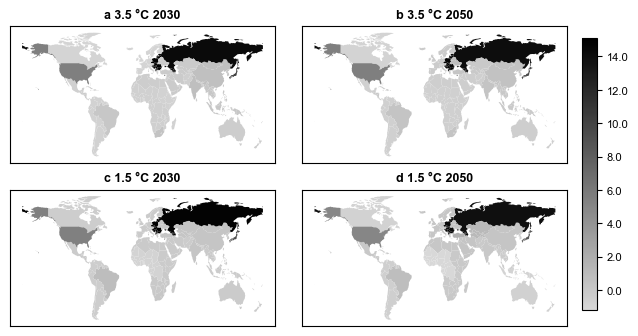

In [17]:
ammoniaRCP6DF = ammoniaGWPDF[ammoniaGWPDF['Database'].str.contains('RCP6')]
fossilAmmoniaRCP6DF = ammoniaRCP6DF[ammoniaRCP6DF['Activity'].str.contains('ammonia, BAU')]
fossilAmmoniaRCP6DF2030 = fossilAmmoniaRCP6DF[fossilAmmoniaRCP6DF['Database'].str.contains('2030')].copy()
fossilAmmoniaRCP6DF2030GLOGWP = list(fossilAmmoniaRCP6DF2030[
    fossilAmmoniaRCP6DF2030['Location'] == 'GLO'
]['GWP'])
fossilAmmoniaRCP6DF2030.loc[:, 'Percent'] = (
    (fossilAmmoniaRCP6DF2030['GWP'] - fossilAmmoniaRCP6DF2030GLOGWP[0]) / fossilAmmoniaRCP6DF2030GLOGWP[0] * 100
)
fossilAmmoniaRCP6DF2030 = fossilAmmoniaRCP6DF2030[fossilAmmoniaRCP6DF2030['Location'] != 'GLO']
fossilAmmoniaRCP6DF2050 = fossilAmmoniaRCP6DF[fossilAmmoniaRCP6DF['Database'].str.contains('2050')].copy()
fossilAmmoniaRCP6DF2050GLOGWP = list(fossilAmmoniaRCP6DF2050[
    fossilAmmoniaRCP6DF2050['Location'] == 'GLO'
]['GWP'])
fossilAmmoniaRCP6DF2050.loc[:, 'Percent'] = (
    (fossilAmmoniaRCP6DF2050['GWP'] - fossilAmmoniaRCP6DF2050GLOGWP[0]) / fossilAmmoniaRCP6DF2050GLOGWP[0] * 100
)
fossilAmmoniaRCP6DF2050 = fossilAmmoniaRCP6DF2050[fossilAmmoniaRCP6DF2050['Location'] != 'GLO']

ammoniaRCP19DF = ammoniaGWPDF[ammoniaGWPDF['Database'].str.contains('RCP19')]
fossilAmmoniaRCP19DF = ammoniaRCP19DF[ammoniaRCP19DF['Activity'].str.contains('ammonia, BAU')]
fossilAmmoniaRCP19DF2030 = fossilAmmoniaRCP19DF[fossilAmmoniaRCP19DF['Database'].str.contains('2030')].copy()
fossilAmmoniaRCP19DF2030GLOGWP = list(fossilAmmoniaRCP19DF2030[
    fossilAmmoniaRCP19DF2030['Location'] == 'GLO'
]['GWP'])
fossilAmmoniaRCP19DF2030.loc[:, 'Percent'] = (
    (fossilAmmoniaRCP19DF2030['GWP'] - fossilAmmoniaRCP19DF2030GLOGWP[0]) / fossilAmmoniaRCP19DF2030GLOGWP[0] * 100
)
fossilAmmoniaRCP19DF2030 = fossilAmmoniaRCP19DF2030[fossilAmmoniaRCP19DF2030['Location'] != 'GLO']
fossilAmmoniaRCP19DF2050 = fossilAmmoniaRCP19DF[fossilAmmoniaRCP19DF['Database'].str.contains('2050')].copy()
fossilAmmoniaRCP19DF2050GLOGWP = list(fossilAmmoniaRCP19DF2050[
    fossilAmmoniaRCP19DF2050['Location'] == 'GLO'
]['GWP'])
fossilAmmoniaRCP19DF2050.loc[:, 'Percent'] = (
    (fossilAmmoniaRCP19DF2050['GWP'] - fossilAmmoniaRCP19DF2050GLOGWP[0]) / fossilAmmoniaRCP19DF2050GLOGWP[0] * 100
)
fossilAmmoniaRCP19DF2050 = fossilAmmoniaRCP19DF2050[fossilAmmoniaRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Fossil ammonia percent regional', fossilAmmoniaRCP6DF2030, fossilAmmoniaRCP19DF2030, fossilAmmoniaRCP6DF2050, fossilAmmoniaRCP19DF2050, customFossilMap)

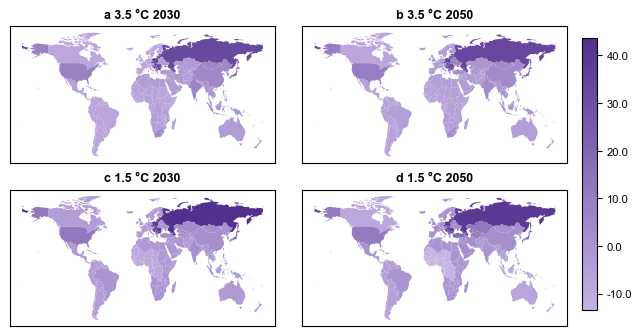

In [18]:
ammoniaRCP6DF = ammoniaGWPDF[ammoniaGWPDF['Database'].str.contains('RCP6')]
blueAmmoniaRCP6DF = ammoniaRCP6DF[ammoniaRCP6DF['Activity'].str.contains('ammonia, blue')]
blueAmmoniaRCP6DF2030 = blueAmmoniaRCP6DF[blueAmmoniaRCP6DF['Database'].str.contains('2030')].copy()
blueAmmoniaRCP6DF2030GLOGWP = list(blueAmmoniaRCP6DF2030[
    blueAmmoniaRCP6DF2030['Location'] == 'GLO'
]['GWP'])
blueAmmoniaRCP6DF2030.loc[:, 'Percent'] = (
    (blueAmmoniaRCP6DF2030['GWP'] - blueAmmoniaRCP6DF2030GLOGWP[0]) / blueAmmoniaRCP6DF2030GLOGWP[0] * 100
)
blueAmmoniaRCP6DF2030 = blueAmmoniaRCP6DF2030[blueAmmoniaRCP6DF2030['Location'] != 'GLO']
blueAmmoniaRCP6DF2050 = blueAmmoniaRCP6DF[blueAmmoniaRCP6DF['Database'].str.contains('2050')].copy()
blueAmmoniaRCP6DF2050GLOGWP = list(blueAmmoniaRCP6DF2050[
    blueAmmoniaRCP6DF2050['Location'] == 'GLO'
]['GWP'])
blueAmmoniaRCP6DF2050.loc[:, 'Percent'] = (
    (blueAmmoniaRCP6DF2050['GWP'] - blueAmmoniaRCP6DF2050GLOGWP[0]) / blueAmmoniaRCP6DF2050GLOGWP[0] * 100
)
blueAmmoniaRCP6DF2050 = blueAmmoniaRCP6DF2050[blueAmmoniaRCP6DF2050['Location'] != 'GLO']

ammoniaRCP19DF = ammoniaGWPDF[ammoniaGWPDF['Database'].str.contains('RCP19')]
blueAmmoniaRCP19DF = ammoniaRCP19DF[ammoniaRCP19DF['Activity'].str.contains('ammonia, blue')]
blueAmmoniaRCP19DF2030 = blueAmmoniaRCP19DF[blueAmmoniaRCP19DF['Database'].str.contains('2030')].copy()
blueAmmoniaRCP19DF2030GLOGWP = list(blueAmmoniaRCP19DF2030[
    blueAmmoniaRCP19DF2030['Location'] == 'GLO'
]['GWP'])
blueAmmoniaRCP19DF2030.loc[:, 'Percent'] = (
    (blueAmmoniaRCP19DF2030['GWP'] - blueAmmoniaRCP19DF2030GLOGWP[0]) / blueAmmoniaRCP19DF2030GLOGWP[0] * 100
)
blueAmmoniaRCP19DF2030 = blueAmmoniaRCP19DF2030[blueAmmoniaRCP19DF2030['Location'] != 'GLO']
blueAmmoniaRCP19DF2050 = blueAmmoniaRCP19DF[blueAmmoniaRCP19DF['Database'].str.contains('2050')].copy()
blueAmmoniaRCP19DF2050GLOGWP = list(blueAmmoniaRCP19DF2050[
    blueAmmoniaRCP19DF2050['Location'] == 'GLO'
]['GWP'])
blueAmmoniaRCP19DF2050.loc[:, 'Percent'] = (
    (blueAmmoniaRCP19DF2050['GWP'] - blueAmmoniaRCP19DF2050GLOGWP[0]) / blueAmmoniaRCP19DF2050GLOGWP[0] * 100
)
blueAmmoniaRCP19DF2050 = blueAmmoniaRCP19DF2050[blueAmmoniaRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Blue ammonia percent regional', blueAmmoniaRCP6DF2030, blueAmmoniaRCP19DF2030, blueAmmoniaRCP6DF2050, blueAmmoniaRCP19DF2050, customBlueMap)

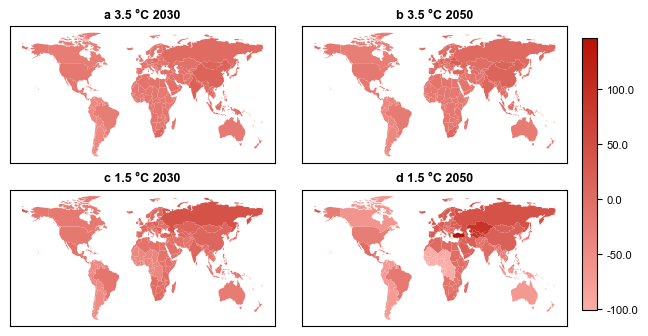

In [19]:
ammoniaRCP6DF = ammoniaGWPDF[ammoniaGWPDF['Database'].str.contains('RCP6')]
solarAmmoniaRCP6DF = ammoniaRCP6DF[ammoniaRCP6DF['Activity'].str.contains('solar')]
solarAmmoniaRCP6DF2030 = solarAmmoniaRCP6DF[solarAmmoniaRCP6DF['Database'].str.contains('2030')].copy()
solarAmmoniaRCP6DF2030GLOGWP = list(solarAmmoniaRCP6DF2030[
    solarAmmoniaRCP6DF2030['Location'] == 'GLO'
]['GWP'])
solarAmmoniaRCP6DF2030.loc[:, 'Percent'] = (
    (solarAmmoniaRCP6DF2030['GWP'] - solarAmmoniaRCP6DF2030GLOGWP[0]) / solarAmmoniaRCP6DF2030GLOGWP[0] * 100
)
solarAmmoniaRCP6DF2030 = solarAmmoniaRCP6DF2030[solarAmmoniaRCP6DF2030['Location'] != 'GLO']
solarAmmoniaRCP6DF2050 = solarAmmoniaRCP6DF[solarAmmoniaRCP6DF['Database'].str.contains('2050')].copy()
solarAmmoniaRCP6DF2050GLOGWP = list(solarAmmoniaRCP6DF2050[
    solarAmmoniaRCP6DF2050['Location'] == 'GLO'
]['GWP'])
solarAmmoniaRCP6DF2050.loc[:, 'Percent'] = (
    (solarAmmoniaRCP6DF2050['GWP'] - solarAmmoniaRCP6DF2050GLOGWP[0]) / solarAmmoniaRCP6DF2050GLOGWP[0] * 100
)
solarAmmoniaRCP6DF2050 = solarAmmoniaRCP6DF2050[solarAmmoniaRCP6DF2050['Location'] != 'GLO']

ammoniaRCP19DF = ammoniaGWPDF[ammoniaGWPDF['Database'].str.contains('RCP19')]
solarAmmoniaRCP19DF = ammoniaRCP19DF[ammoniaRCP19DF['Activity'].str.contains('solar')]
solarAmmoniaRCP19DF2030 = solarAmmoniaRCP19DF[solarAmmoniaRCP19DF['Database'].str.contains('2030')].copy()
solarAmmoniaRCP19DF2030GLOGWP = list(solarAmmoniaRCP19DF2030[
    solarAmmoniaRCP19DF2030['Location'] == 'GLO'
]['GWP'])
solarAmmoniaRCP19DF2030.loc[:, 'Percent'] = (
    (solarAmmoniaRCP19DF2030['GWP'] - solarAmmoniaRCP19DF2030GLOGWP[0]) / solarAmmoniaRCP19DF2030GLOGWP[0] * 100
)
solarAmmoniaRCP19DF2030 = solarAmmoniaRCP19DF2030[solarAmmoniaRCP19DF2030['Location'] != 'GLO']
solarAmmoniaRCP19DF2050 = solarAmmoniaRCP19DF[solarAmmoniaRCP19DF['Database'].str.contains('2050')].copy()
solarAmmoniaRCP19DF2050GLOGWP = list(solarAmmoniaRCP19DF2050[
    solarAmmoniaRCP19DF2050['Location'] == 'GLO'
]['GWP'])
solarAmmoniaRCP19DF2050.loc[:, 'Percent'] = (
    (solarAmmoniaRCP19DF2050['GWP'] - solarAmmoniaRCP19DF2050GLOGWP[0]) / solarAmmoniaRCP19DF2050GLOGWP[0] * 100
)
solarAmmoniaRCP19DF2050 = solarAmmoniaRCP19DF2050[solarAmmoniaRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Solar ammonia percent regional', solarAmmoniaRCP6DF2030, solarAmmoniaRCP19DF2030, solarAmmoniaRCP6DF2050, solarAmmoniaRCP19DF2050, customSolarMap)

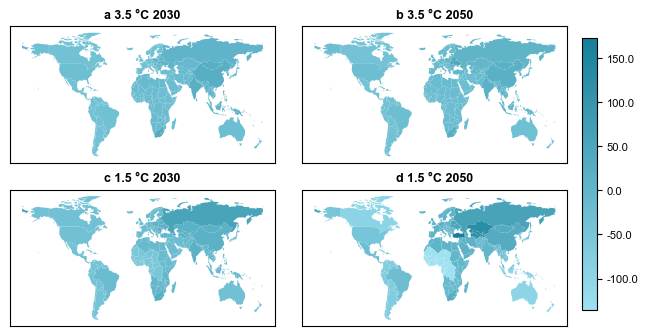

In [20]:
ammoniaRCP6DF = ammoniaGWPDF[ammoniaGWPDF['Database'].str.contains('RCP6')]
windAmmoniaRCP6DF = ammoniaRCP6DF[ammoniaRCP6DF['Activity'].str.contains('onshore wind')]
windAmmoniaRCP6DF2030 = windAmmoniaRCP6DF[windAmmoniaRCP6DF['Database'].str.contains('2030')].copy()
windAmmoniaRCP6DF2030GLOGWP = list(windAmmoniaRCP6DF2030[
    windAmmoniaRCP6DF2030['Location'] == 'GLO'
]['GWP'])
windAmmoniaRCP6DF2030.loc[:, 'Percent'] = (
    (windAmmoniaRCP6DF2030['GWP'] - windAmmoniaRCP6DF2030GLOGWP[0]) / windAmmoniaRCP6DF2030GLOGWP[0] * 100
)
windAmmoniaRCP6DF2030 = windAmmoniaRCP6DF2030[windAmmoniaRCP6DF2030['Location'] != 'GLO']
windAmmoniaRCP6DF2050 = windAmmoniaRCP6DF[windAmmoniaRCP6DF['Database'].str.contains('2050')].copy()
windAmmoniaRCP6DF2050GLOGWP = list(windAmmoniaRCP6DF2050[
    windAmmoniaRCP6DF2050['Location'] == 'GLO'
]['GWP'])
windAmmoniaRCP6DF2050.loc[:, 'Percent'] = (
    (windAmmoniaRCP6DF2050['GWP'] - windAmmoniaRCP6DF2050GLOGWP[0]) / windAmmoniaRCP6DF2050GLOGWP[0] * 100
)
windAmmoniaRCP6DF2050 = windAmmoniaRCP6DF2050[windAmmoniaRCP6DF2050['Location'] != 'GLO']

ammoniaRCP19DF = ammoniaGWPDF[ammoniaGWPDF['Database'].str.contains('RCP19')]
windAmmoniaRCP19DF = ammoniaRCP19DF[ammoniaRCP19DF['Activity'].str.contains('onshore wind')]
windAmmoniaRCP19DF2030 = windAmmoniaRCP19DF[windAmmoniaRCP19DF['Database'].str.contains('2030')].copy()
windAmmoniaRCP19DF2030GLOGWP = list(windAmmoniaRCP19DF2030[
    windAmmoniaRCP19DF2030['Location'] == 'GLO'
]['GWP'])
windAmmoniaRCP19DF2030.loc[:, 'Percent'] = (
    (windAmmoniaRCP19DF2030['GWP'] - windAmmoniaRCP19DF2030GLOGWP[0]) / windAmmoniaRCP19DF2030GLOGWP[0] * 100
)
windAmmoniaRCP19DF2030 = windAmmoniaRCP19DF2030[windAmmoniaRCP19DF2030['Location'] != 'GLO']
windAmmoniaRCP19DF2050 = windAmmoniaRCP19DF[windAmmoniaRCP19DF['Database'].str.contains('2050')].copy()
windAmmoniaRCP19DF2050GLOGWP = list(windAmmoniaRCP19DF2050[
    windAmmoniaRCP19DF2050['Location'] == 'GLO'
]['GWP'])
windAmmoniaRCP19DF2050.loc[:, 'Percent'] = (
    (windAmmoniaRCP19DF2050['GWP'] - windAmmoniaRCP19DF2050GLOGWP[0]) / windAmmoniaRCP19DF2050GLOGWP[0] * 100
)
windAmmoniaRCP19DF2050 = windAmmoniaRCP19DF2050[windAmmoniaRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Wind ammonia percent regional', windAmmoniaRCP6DF2030, windAmmoniaRCP19DF2030, windAmmoniaRCP6DF2050, windAmmoniaRCP19DF2050, customWindMap)

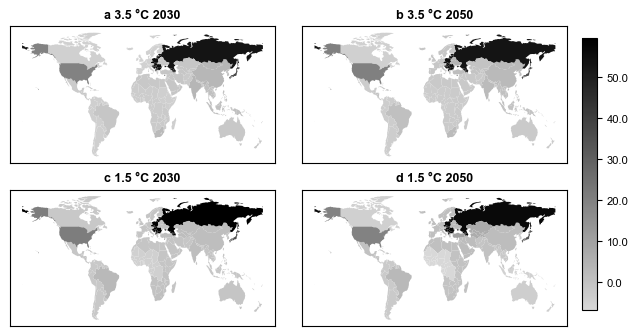

In [21]:
methanolRCP6DF = methanolGWPDF[methanolGWPDF['Database'].str.contains('RCP6')]
fossilMethanolRCP6DF = methanolRCP6DF[methanolRCP6DF['Activity'].str.contains('methanol, BAU')]
fossilMethanolRCP6DF2030 = fossilMethanolRCP6DF[fossilMethanolRCP6DF['Database'].str.contains('2030')].copy()
fossilMethanolRCP6DF2030GLOGWP = list(fossilMethanolRCP6DF2030[
    fossilMethanolRCP6DF2030['Location'] == 'GLO'
]['GWP'])
fossilMethanolRCP6DF2030.loc[:, 'Percent'] = (
    (fossilMethanolRCP6DF2030['GWP'] - fossilMethanolRCP6DF2030GLOGWP[0]) / fossilMethanolRCP6DF2030GLOGWP[0] * 100
)
fossilMethanolRCP6DF2030 = fossilMethanolRCP6DF2030[fossilMethanolRCP6DF2030['Location'] != 'GLO']
fossilMethanolRCP6DF2050 = fossilMethanolRCP6DF[fossilMethanolRCP6DF['Database'].str.contains('2050')].copy()
fossilMethanolRCP6DF2050GLOGWP = list(fossilMethanolRCP6DF2050[
    fossilMethanolRCP6DF2050['Location'] == 'GLO'
]['GWP'])
fossilMethanolRCP6DF2050.loc[:, 'Percent'] = (
    (fossilMethanolRCP6DF2050['GWP'] - fossilMethanolRCP6DF2050GLOGWP[0]) / fossilMethanolRCP6DF2050GLOGWP[0] * 100
)
fossilMethanolRCP6DF2050 = fossilMethanolRCP6DF2050[fossilMethanolRCP6DF2050['Location'] != 'GLO']

methanolRCP19DF = methanolGWPDF[methanolGWPDF['Database'].str.contains('RCP19')]
fossilMethanolRCP19DF = methanolRCP19DF[methanolRCP19DF['Activity'].str.contains('methanol, BAU')]
fossilMethanolRCP19DF2030 = fossilMethanolRCP19DF[fossilMethanolRCP19DF['Database'].str.contains('2030')].copy()
fossilMethanolRCP19DF2030GLOGWP = list(fossilMethanolRCP19DF2030[
    fossilMethanolRCP19DF2030['Location'] == 'GLO'
]['GWP'])
fossilMethanolRCP19DF2030.loc[:, 'Percent'] = (
    (fossilMethanolRCP19DF2030['GWP'] - fossilMethanolRCP19DF2030GLOGWP[0]) / fossilMethanolRCP19DF2030GLOGWP[0] * 100
)
fossilMethanolRCP19DF2030 = fossilMethanolRCP19DF2030[fossilMethanolRCP19DF2030['Location'] != 'GLO']
fossilMethanolRCP19DF2050 = fossilMethanolRCP19DF[fossilMethanolRCP19DF['Database'].str.contains('2050')].copy()
fossilMethanolRCP19DF2050GLOGWP = list(fossilMethanolRCP19DF2050[
    fossilMethanolRCP19DF2050['Location'] == 'GLO'
]['GWP'])
fossilMethanolRCP19DF2050.loc[:, 'Percent'] = (
    (fossilMethanolRCP19DF2050['GWP'] - fossilMethanolRCP19DF2050GLOGWP[0]) / fossilMethanolRCP19DF2050GLOGWP[0] * 100
)
fossilMethanolRCP19DF2050 = fossilMethanolRCP19DF2050[fossilMethanolRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Fossil methanol percent regional', fossilMethanolRCP6DF2030, fossilMethanolRCP19DF2030, fossilMethanolRCP6DF2050, fossilMethanolRCP19DF2050, customFossilMap)

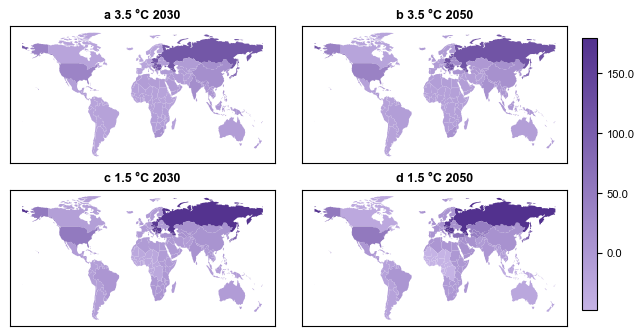

In [22]:
methanolRCP6DF = methanolGWPDF[methanolGWPDF['Database'].str.contains('RCP6')]
blueMethanolRCP6DF = methanolRCP6DF[methanolRCP6DF['Activity'].str.contains('methanol, blue')]
blueMethanolRCP6DF2030 = blueMethanolRCP6DF[blueMethanolRCP6DF['Database'].str.contains('2030')].copy()
blueMethanolRCP6DF2030GLOGWP = list(blueMethanolRCP6DF2030[
    blueMethanolRCP6DF2030['Location'] == 'GLO'
]['GWP'])
blueMethanolRCP6DF2030.loc[:, 'Percent'] = (
    (blueMethanolRCP6DF2030['GWP'] - blueMethanolRCP6DF2030GLOGWP[0]) / blueMethanolRCP6DF2030GLOGWP[0] * 100
)
blueMethanolRCP6DF2030 = blueMethanolRCP6DF2030[blueMethanolRCP6DF2030['Location'] != 'GLO']
blueMethanolRCP6DF2050 = blueMethanolRCP6DF[blueMethanolRCP6DF['Database'].str.contains('2050')].copy()
blueMethanolRCP6DF2050GLOGWP = list(blueMethanolRCP6DF2050[
    blueMethanolRCP6DF2050['Location'] == 'GLO'
]['GWP'])
blueMethanolRCP6DF2050.loc[:, 'Percent'] = (
    (blueMethanolRCP6DF2050['GWP'] - blueMethanolRCP6DF2050GLOGWP[0]) / blueMethanolRCP6DF2050GLOGWP[0] * 100
)
blueMethanolRCP6DF2050 = blueMethanolRCP6DF2050[blueMethanolRCP6DF2050['Location'] != 'GLO']

methanolRCP19DF = methanolGWPDF[methanolGWPDF['Database'].str.contains('RCP19')]
blueMethanolRCP19DF = methanolRCP19DF[methanolRCP19DF['Activity'].str.contains('methanol, blue')]
blueMethanolRCP19DF2030 = blueMethanolRCP19DF[blueMethanolRCP19DF['Database'].str.contains('2030')].copy()
blueMethanolRCP19DF2030GLOGWP = list(blueMethanolRCP19DF2030[
    blueMethanolRCP19DF2030['Location'] == 'GLO'
]['GWP'])
blueMethanolRCP19DF2030.loc[:, 'Percent'] = (
    (blueMethanolRCP19DF2030['GWP'] - blueMethanolRCP19DF2030GLOGWP[0]) / blueMethanolRCP19DF2030GLOGWP[0] * 100
)
blueMethanolRCP19DF2030 = blueMethanolRCP19DF2030[blueMethanolRCP19DF2030['Location'] != 'GLO']
blueMethanolRCP19DF2050 = blueMethanolRCP19DF[blueMethanolRCP19DF['Database'].str.contains('2050')].copy()
blueMethanolRCP19DF2050GLOGWP = list(blueMethanolRCP19DF2050[
    blueMethanolRCP19DF2050['Location'] == 'GLO'
]['GWP'])
blueMethanolRCP19DF2050.loc[:, 'Percent'] = (
    (blueMethanolRCP19DF2050['GWP'] - blueMethanolRCP19DF2050GLOGWP[0]) / blueMethanolRCP19DF2050GLOGWP[0] * 100
)
blueMethanolRCP19DF2050 = blueMethanolRCP19DF2050[blueMethanolRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Blue methanol percent regional', blueMethanolRCP6DF2030, blueMethanolRCP19DF2030, blueMethanolRCP6DF2050, blueMethanolRCP19DF2050, customBlueMap)

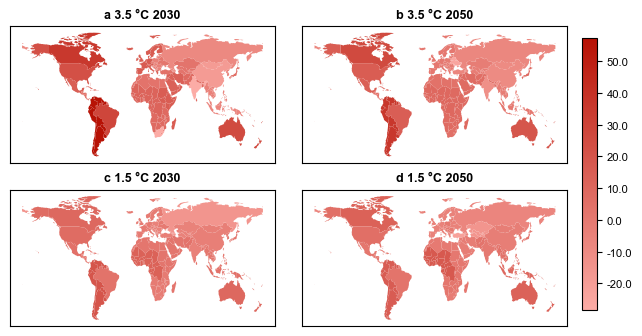

In [23]:
methanolRCP6DF = methanolGWPDF[methanolGWPDF['Database'].str.contains('RCP6')]
solarMethanolRCP6DF = methanolRCP6DF[methanolRCP6DF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
solarMethanolRCP6DF2030 = solarMethanolRCP6DF[solarMethanolRCP6DF['Database'].str.contains('2030')].copy()
solarMethanolRCP6DF2030GLOGWP = list(solarMethanolRCP6DF2030[
    solarMethanolRCP6DF2030['Location'] == 'GLO'
]['GWP'])
solarMethanolRCP6DF2030.loc[:, 'Percent'] = (
    (solarMethanolRCP6DF2030['GWP'] - solarMethanolRCP6DF2030GLOGWP[0]) / solarMethanolRCP6DF2030GLOGWP[0] * 100
)
solarMethanolRCP6DF2030 = solarMethanolRCP6DF2030[solarMethanolRCP6DF2030['Location'] != 'GLO']
solarMethanolRCP6DF2050 = solarMethanolRCP6DF[solarMethanolRCP6DF['Database'].str.contains('2050')].copy()
solarMethanolRCP6DF2050GLOGWP = list(solarMethanolRCP6DF2050[
    solarMethanolRCP6DF2050['Location'] == 'GLO'
]['GWP'])
solarMethanolRCP6DF2050.loc[:, 'Percent'] = (
    (solarMethanolRCP6DF2050['GWP'] - solarMethanolRCP6DF2050GLOGWP[0]) / solarMethanolRCP6DF2050GLOGWP[0] * 100
)
solarMethanolRCP6DF2050 = solarMethanolRCP6DF2050[solarMethanolRCP6DF2050['Location'] != 'GLO']

methanolRCP19DF = methanolGWPDF[methanolGWPDF['Database'].str.contains('RCP19')]
solarMethanolRCP19DF = methanolRCP19DF[methanolRCP19DF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
solarMethanolRCP19DF2030 = solarMethanolRCP19DF[solarMethanolRCP19DF['Database'].str.contains('2030')].copy()
solarMethanolRCP19DF2030GLOGWP = list(solarMethanolRCP19DF2030[
    solarMethanolRCP19DF2030['Location'] == 'GLO'
]['GWP'])
solarMethanolRCP19DF2030.loc[:, 'Percent'] = (
    (solarMethanolRCP19DF2030['GWP'] - solarMethanolRCP19DF2030GLOGWP[0]) / solarMethanolRCP19DF2030GLOGWP[0] * 100
)
solarMethanolRCP19DF2030 = solarMethanolRCP19DF2030[solarMethanolRCP19DF2030['Location'] != 'GLO']
solarMethanolRCP19DF2050 = solarMethanolRCP19DF[solarMethanolRCP19DF['Database'].str.contains('2050')].copy()
solarMethanolRCP19DF2050GLOGWP = list(solarMethanolRCP19DF2050[
    solarMethanolRCP19DF2050['Location'] == 'GLO'
]['GWP'])
solarMethanolRCP19DF2050.loc[:, 'Percent'] = (
    (solarMethanolRCP19DF2050['GWP'] - solarMethanolRCP19DF2050GLOGWP[0]) / solarMethanolRCP19DF2050GLOGWP[0] * 100
)
solarMethanolRCP19DF2050 = solarMethanolRCP19DF2050[solarMethanolRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Solar methanol percent regional', solarMethanolRCP6DF2030, solarMethanolRCP19DF2030, solarMethanolRCP6DF2050, solarMethanolRCP19DF2050, customSolarMap)

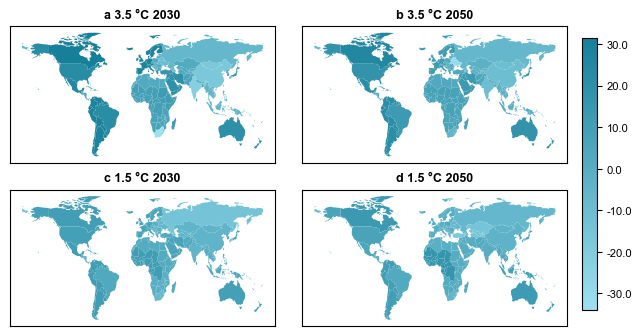

In [24]:
methanolRCP6DF = methanolGWPDF[methanolGWPDF['Database'].str.contains('RCP6')]
windMethanolRCP6DF = methanolRCP6DF[methanolRCP6DF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
windMethanolRCP6DF2030 = windMethanolRCP6DF[windMethanolRCP6DF['Database'].str.contains('2030')].copy()
windMethanolRCP6DF2030GLOGWP = list(windMethanolRCP6DF2030[
    windMethanolRCP6DF2030['Location'] == 'GLO'
]['GWP'])
windMethanolRCP6DF2030.loc[:, 'Percent'] = (
    (windMethanolRCP6DF2030['GWP'] - windMethanolRCP6DF2030GLOGWP[0]) / windMethanolRCP6DF2030GLOGWP[0] * 100
)
windMethanolRCP6DF2030 = windMethanolRCP6DF2030[windMethanolRCP6DF2030['Location'] != 'GLO']
windMethanolRCP6DF2050 = windMethanolRCP6DF[windMethanolRCP6DF['Database'].str.contains('2050')].copy()
windMethanolRCP6DF2050GLOGWP = list(windMethanolRCP6DF2050[
    windMethanolRCP6DF2050['Location'] == 'GLO'
]['GWP'])
windMethanolRCP6DF2050.loc[:, 'Percent'] = (
    (windMethanolRCP6DF2050['GWP'] - windMethanolRCP6DF2050GLOGWP[0]) / windMethanolRCP6DF2050GLOGWP[0] * 100
)
windMethanolRCP6DF2050 = windMethanolRCP6DF2050[windMethanolRCP6DF2050['Location'] != 'GLO']

methanolRCP19DF = methanolGWPDF[methanolGWPDF['Database'].str.contains('RCP19')]
windMethanolRCP19DF = methanolRCP19DF[methanolRCP19DF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
windMethanolRCP19DF2030 = windMethanolRCP19DF[windMethanolRCP19DF['Database'].str.contains('2030')].copy()
windMethanolRCP19DF2030GLOGWP = list(windMethanolRCP19DF2030[
    windMethanolRCP19DF2030['Location'] == 'GLO'
]['GWP'])
windMethanolRCP19DF2030.loc[:, 'Percent'] = (
    (windMethanolRCP19DF2030['GWP'] - windMethanolRCP19DF2030GLOGWP[0]) / windMethanolRCP19DF2030GLOGWP[0] * 100
)
windMethanolRCP19DF2030 = windMethanolRCP19DF2030[windMethanolRCP19DF2030['Location'] != 'GLO']
windMethanolRCP19DF2050 = windMethanolRCP19DF[windMethanolRCP19DF['Database'].str.contains('2050')].copy()
windMethanolRCP19DF2050GLOGWP = list(windMethanolRCP19DF2050[
    windMethanolRCP19DF2050['Location'] == 'GLO'
]['GWP'])
windMethanolRCP19DF2050.loc[:, 'Percent'] = (
    (windMethanolRCP19DF2050['GWP'] - windMethanolRCP19DF2050GLOGWP[0]) / windMethanolRCP19DF2050GLOGWP[0] * 100
)
windMethanolRCP19DF2050 = windMethanolRCP19DF2050[windMethanolRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Wind methanol percent regional', windMethanolRCP6DF2030, windMethanolRCP19DF2030, windMethanolRCP6DF2050, windMethanolRCP19DF2050, customWindMap)

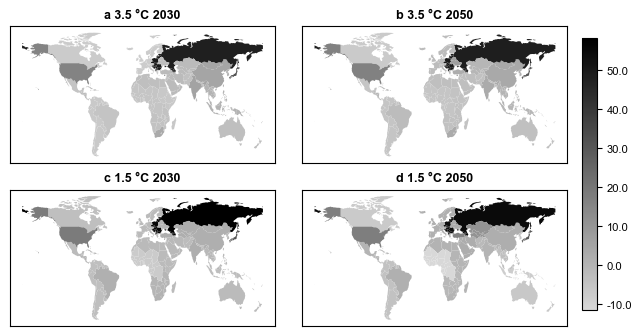

In [25]:
ethyleneRCP6DF = ethyleneGWPDF[ethyleneGWPDF['Database'].str.contains('RCP6')]
fossilEthyleneRCP6DF = ethyleneRCP6DF[ethyleneRCP6DF['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
fossilEthyleneRCP6DF2030 = fossilEthyleneRCP6DF[fossilEthyleneRCP6DF['Database'].str.contains('2030')].copy()
fossilEthyleneRCP6DF2030GLOGWP = list(fossilEthyleneRCP6DF2030[
    fossilEthyleneRCP6DF2030['Location'] == 'GLO'
]['GWP'])
fossilEthyleneRCP6DF2030.loc[:, 'Percent'] = (
    (fossilEthyleneRCP6DF2030['GWP'] - fossilEthyleneRCP6DF2030GLOGWP[0]) / fossilEthyleneRCP6DF2030GLOGWP[0] * 100
)
fossilEthyleneRCP6DF2030 = fossilEthyleneRCP6DF2030[fossilEthyleneRCP6DF2030['Location'] != 'GLO']
fossilEthyleneRCP6DF2050 = fossilEthyleneRCP6DF[fossilEthyleneRCP6DF['Database'].str.contains('2050')].copy()
fossilEthyleneRCP6DF2050GLOGWP = list(fossilEthyleneRCP6DF2050[
    fossilEthyleneRCP6DF2050['Location'] == 'GLO'
]['GWP'])
fossilEthyleneRCP6DF2050.loc[:, 'Percent'] = (
    (fossilEthyleneRCP6DF2050['GWP'] - fossilEthyleneRCP6DF2050GLOGWP[0]) / fossilEthyleneRCP6DF2050GLOGWP[0] * 100
)
fossilEthyleneRCP6DF2050 = fossilEthyleneRCP6DF2050[fossilEthyleneRCP6DF2050['Location'] != 'GLO']

ethyleneRCP19DF = ethyleneGWPDF[ethyleneGWPDF['Database'].str.contains('RCP19')]
fossilEthyleneRCP19DF = ethyleneRCP19DF[ethyleneRCP19DF['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
fossilEthyleneRCP19DF2030 = fossilEthyleneRCP19DF[fossilEthyleneRCP19DF['Database'].str.contains('2030')].copy()
fossilEthyleneRCP19DF2030GLOGWP = list(fossilEthyleneRCP19DF2030[
    fossilEthyleneRCP19DF2030['Location'] == 'GLO'
]['GWP'])
fossilEthyleneRCP19DF2030.loc[:, 'Percent'] = (
    (fossilEthyleneRCP19DF2030['GWP'] - fossilEthyleneRCP19DF2030GLOGWP[0]) / fossilEthyleneRCP19DF2030GLOGWP[0] * 100
)
fossilEthyleneRCP19DF2030 = fossilEthyleneRCP19DF2030[fossilEthyleneRCP19DF2030['Location'] != 'GLO']
fossilEthyleneRCP19DF2050 = fossilEthyleneRCP19DF[fossilEthyleneRCP19DF['Database'].str.contains('2050')].copy()
fossilEthyleneRCP19DF2050GLOGWP = list(fossilEthyleneRCP19DF2050[
    fossilEthyleneRCP19DF2050['Location'] == 'GLO'
]['GWP'])
fossilEthyleneRCP19DF2050.loc[:, 'Percent'] = (
    (fossilEthyleneRCP19DF2050['GWP'] - fossilEthyleneRCP19DF2050GLOGWP[0]) / fossilEthyleneRCP19DF2050GLOGWP[0] * 100
)
fossilEthyleneRCP19DF2050 = fossilEthyleneRCP19DF2050[fossilEthyleneRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Fossil ethylene percent regional', fossilEthyleneRCP6DF2030, fossilEthyleneRCP19DF2030, fossilEthyleneRCP6DF2050, fossilEthyleneRCP19DF2050, customFossilMap)

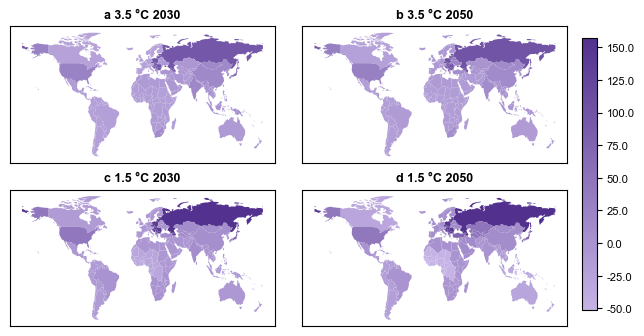

In [26]:
ethyleneRCP6DF = ethyleneGWPDF[ethyleneGWPDF['Database'].str.contains('RCP6')]
blueEthyleneRCP6DF = ethyleneRCP6DF[ethyleneRCP6DF['Activity'].str.contains('ethylene, MTO; methanol, blue')]
blueEthyleneRCP6DF2030 = blueEthyleneRCP6DF[blueEthyleneRCP6DF['Database'].str.contains('2030')].copy()
blueEthyleneRCP6DF2030GLOGWP = list(blueEthyleneRCP6DF2030[
    blueEthyleneRCP6DF2030['Location'] == 'GLO'
]['GWP'])
blueEthyleneRCP6DF2030.loc[:, 'Percent'] = (
    (blueEthyleneRCP6DF2030['GWP'] - blueEthyleneRCP6DF2030GLOGWP[0]) / blueEthyleneRCP6DF2030GLOGWP[0] * 100
)
blueEthyleneRCP6DF2030 = blueEthyleneRCP6DF2030[blueEthyleneRCP6DF2030['Location'] != 'GLO']
blueEthyleneRCP6DF2050 = blueEthyleneRCP6DF[blueEthyleneRCP6DF['Database'].str.contains('2050')].copy()
blueEthyleneRCP6DF2050GLOGWP = list(blueEthyleneRCP6DF2050[
    blueEthyleneRCP6DF2050['Location'] == 'GLO'
]['GWP'])
blueEthyleneRCP6DF2050.loc[:, 'Percent'] = (
    (blueEthyleneRCP6DF2050['GWP'] - blueEthyleneRCP6DF2050GLOGWP[0]) / blueEthyleneRCP6DF2050GLOGWP[0] * 100
)
blueEthyleneRCP6DF2050 = blueEthyleneRCP6DF2050[blueEthyleneRCP6DF2050['Location'] != 'GLO']

ethyleneRCP19DF = ethyleneGWPDF[ethyleneGWPDF['Database'].str.contains('RCP19')]
blueEthyleneRCP19DF = ethyleneRCP19DF[ethyleneRCP19DF['Activity'].str.contains('ethylene, MTO; methanol, blue')]
blueEthyleneRCP19DF2030 = blueEthyleneRCP19DF[blueEthyleneRCP19DF['Database'].str.contains('2030')].copy()
blueEthyleneRCP19DF2030GLOGWP = list(blueEthyleneRCP19DF2030[
    blueEthyleneRCP19DF2030['Location'] == 'GLO'
]['GWP'])
blueEthyleneRCP19DF2030.loc[:, 'Percent'] = (
    (blueEthyleneRCP19DF2030['GWP'] - blueEthyleneRCP19DF2030GLOGWP[0]) / blueEthyleneRCP19DF2030GLOGWP[0] * 100
)
blueEthyleneRCP19DF2030 = blueEthyleneRCP19DF2030[blueEthyleneRCP19DF2030['Location'] != 'GLO']
blueEthyleneRCP19DF2050 = blueEthyleneRCP19DF[blueEthyleneRCP19DF['Database'].str.contains('2050')].copy()
blueEthyleneRCP19DF2050GLOGWP = list(blueEthyleneRCP19DF2050[
    blueEthyleneRCP19DF2050['Location'] == 'GLO'
]['GWP'])
blueEthyleneRCP19DF2050.loc[:, 'Percent'] = (
    (blueEthyleneRCP19DF2050['GWP'] - blueEthyleneRCP19DF2050GLOGWP[0]) / blueEthyleneRCP19DF2050GLOGWP[0] * 100
)
blueEthyleneRCP19DF2050 = blueEthyleneRCP19DF2050[blueEthyleneRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Blue ethylene percent regional', blueEthyleneRCP6DF2030, blueEthyleneRCP19DF2030, blueEthyleneRCP6DF2050, blueEthyleneRCP19DF2050, customBlueMap)

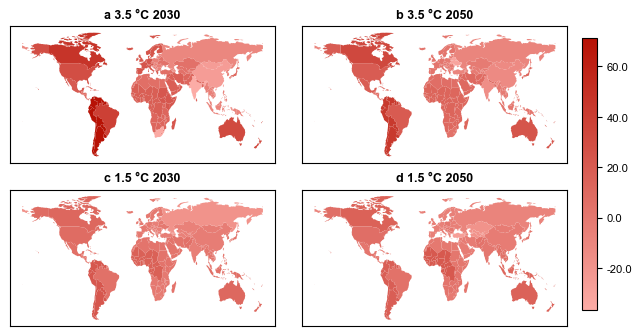

In [27]:
ethyleneRCP6DF = ethyleneGWPDF[ethyleneGWPDF['Database'].str.contains('RCP6')]
solarEthyleneRCP6DF = ethyleneRCP6DF[ethyleneRCP6DF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
solarEthyleneRCP6DF2030 = solarEthyleneRCP6DF[solarEthyleneRCP6DF['Database'].str.contains('2030')].copy()
solarEthyleneRCP6DF2030GLOGWP = list(solarEthyleneRCP6DF2030[
    solarEthyleneRCP6DF2030['Location'] == 'GLO'
]['GWP'])
solarEthyleneRCP6DF2030.loc[:, 'Percent'] = (
    (solarEthyleneRCP6DF2030['GWP'] - solarEthyleneRCP6DF2030GLOGWP[0]) / solarEthyleneRCP6DF2030GLOGWP[0] * 100
)
solarEthyleneRCP6DF2030 = solarEthyleneRCP6DF2030[solarEthyleneRCP6DF2030['Location'] != 'GLO']
solarEthyleneRCP6DF2050 = solarEthyleneRCP6DF[solarEthyleneRCP6DF['Database'].str.contains('2050')].copy()
solarEthyleneRCP6DF2050GLOGWP = list(solarEthyleneRCP6DF2050[
    solarEthyleneRCP6DF2050['Location'] == 'GLO'
]['GWP'])
solarEthyleneRCP6DF2050.loc[:, 'Percent'] = (
    (solarEthyleneRCP6DF2050['GWP'] - solarEthyleneRCP6DF2050GLOGWP[0]) / solarEthyleneRCP6DF2050GLOGWP[0] * 100
)
solarEthyleneRCP6DF2050 = solarEthyleneRCP6DF2050[solarEthyleneRCP6DF2050['Location'] != 'GLO']

ethyleneRCP19DF = ethyleneGWPDF[ethyleneGWPDF['Database'].str.contains('RCP19')]
solarEthyleneRCP19DF = ethyleneRCP19DF[ethyleneRCP19DF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
solarEthyleneRCP19DF2030 = solarEthyleneRCP19DF[solarEthyleneRCP19DF['Database'].str.contains('2030')].copy()
solarEthyleneRCP19DF2030GLOGWP = list(solarEthyleneRCP19DF2030[
    solarEthyleneRCP19DF2030['Location'] == 'GLO'
]['GWP'])
solarEthyleneRCP19DF2030.loc[:, 'Percent'] = (
    (solarEthyleneRCP19DF2030['GWP'] - solarEthyleneRCP19DF2030GLOGWP[0]) / solarEthyleneRCP19DF2030GLOGWP[0] * 100
)
solarEthyleneRCP19DF2030 = solarEthyleneRCP19DF2030[solarEthyleneRCP19DF2030['Location'] != 'GLO']
solarEthyleneRCP19DF2050 = solarEthyleneRCP19DF[solarEthyleneRCP19DF['Database'].str.contains('2050')].copy()
solarEthyleneRCP19DF2050GLOGWP = list(solarEthyleneRCP19DF2050[
    solarEthyleneRCP19DF2050['Location'] == 'GLO'
]['GWP'])
solarEthyleneRCP19DF2050.loc[:, 'Percent'] = (
    (solarEthyleneRCP19DF2050['GWP'] - solarEthyleneRCP19DF2050GLOGWP[0]) / solarEthyleneRCP19DF2050GLOGWP[0] * 100
)
solarEthyleneRCP19DF2050 = solarEthyleneRCP19DF2050[solarEthyleneRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Solar ethylene percent regional', solarEthyleneRCP6DF2030, solarEthyleneRCP19DF2030, solarEthyleneRCP6DF2050, solarEthyleneRCP19DF2050, customSolarMap)

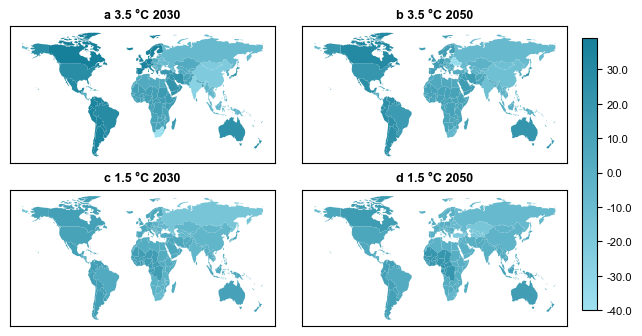

In [28]:
ethyleneRCP6DF = ethyleneGWPDF[ethyleneGWPDF['Database'].str.contains('RCP6')]
windEthyleneRCP6DF = ethyleneRCP6DF[ethyleneRCP6DF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
windEthyleneRCP6DF2030 = windEthyleneRCP6DF[windEthyleneRCP6DF['Database'].str.contains('2030')].copy()
windEthyleneRCP6DF2030GLOGWP = list(windEthyleneRCP6DF2030[
    windEthyleneRCP6DF2030['Location'] == 'GLO'
]['GWP'])
windEthyleneRCP6DF2030.loc[:, 'Percent'] = (
    (windEthyleneRCP6DF2030['GWP'] - windEthyleneRCP6DF2030GLOGWP[0]) / windEthyleneRCP6DF2030GLOGWP[0] * 100
)
windEthyleneRCP6DF2030 = windEthyleneRCP6DF2030[windEthyleneRCP6DF2030['Location'] != 'GLO']
windEthyleneRCP6DF2050 = windEthyleneRCP6DF[windEthyleneRCP6DF['Database'].str.contains('2050')].copy()
windEthyleneRCP6DF2050GLOGWP = list(windEthyleneRCP6DF2050[
    windEthyleneRCP6DF2050['Location'] == 'GLO'
]['GWP'])
windEthyleneRCP6DF2050.loc[:, 'Percent'] = (
    (windEthyleneRCP6DF2050['GWP'] - windEthyleneRCP6DF2050GLOGWP[0]) / windEthyleneRCP6DF2050GLOGWP[0] * 100
)
windEthyleneRCP6DF2050 = windEthyleneRCP6DF2050[windEthyleneRCP6DF2050['Location'] != 'GLO']

ethyleneRCP19DF = ethyleneGWPDF[ethyleneGWPDF['Database'].str.contains('RCP19')]
windEthyleneRCP19DF = ethyleneRCP19DF[ethyleneRCP19DF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
windEthyleneRCP19DF2030 = windEthyleneRCP19DF[windEthyleneRCP19DF['Database'].str.contains('2030')].copy()
windEthyleneRCP19DF2030GLOGWP = list(windEthyleneRCP19DF2030[
    windEthyleneRCP19DF2030['Location'] == 'GLO'
]['GWP'])
windEthyleneRCP19DF2030.loc[:, 'Percent'] = (
    (windEthyleneRCP19DF2030['GWP'] - windEthyleneRCP19DF2030GLOGWP[0]) / windEthyleneRCP19DF2030GLOGWP[0] * 100
)
windEthyleneRCP19DF2030 = windEthyleneRCP19DF2030[windEthyleneRCP19DF2030['Location'] != 'GLO']
windEthyleneRCP19DF2050 = windEthyleneRCP19DF[windEthyleneRCP19DF['Database'].str.contains('2050')].copy()
windEthyleneRCP19DF2050GLOGWP = list(windEthyleneRCP19DF2050[
    windEthyleneRCP19DF2050['Location'] == 'GLO'
]['GWP'])
windEthyleneRCP19DF2050.loc[:, 'Percent'] = (
    (windEthyleneRCP19DF2050['GWP'] - windEthyleneRCP19DF2050GLOGWP[0]) / windEthyleneRCP19DF2050GLOGWP[0] * 100
)
windEthyleneRCP19DF2050 = windEthyleneRCP19DF2050[windEthyleneRCP19DF2050['Location'] != 'GLO']
plot_world_maps('Wind ethylene percent regional', windEthyleneRCP6DF2030, windEthyleneRCP19DF2030, windEthyleneRCP6DF2050, windEthyleneRCP19DF2050, customWindMap)